# Stock Motif Discovery: Do Recurring Chart Patterns Predict Anything?

**Course:** 2110430 — Time Series Mining  
**Project Type:** Motif Discovery + Statistical Analysis on Real Financial Data

## 1. Introduction & Research Question

### The belief we are testing
Technical analysts often claim that certain *chart patterns* (head-and-shoulders, double-tops, flags) repeat across time, and when they appear they *foreshadow* a particular future price movement. If this is true, then whenever we find two windows of price history that look almost identical, the price movement *after* each occurrence should also look similar.

### The research question
> **When the same shape (motif) repeats in a stock's return series, does the move that follows also repeat?**

### Hypotheses
- **H0 (null):** Motif recurrence carries *no* information about the next move. The two occurrences of a motif are followed by same-direction moves only ~50% of the time (a coin flip).
- **H1 (alternative):** The two occurrences of a motif tend to be followed by same-direction moves, at a rate significantly higher than 50%.

### Why this matters
If H0 is rejected, that's evidence that simple shape-matching has predictive power — surprising and useful. If H0 is *not* rejected, that's evidence consistent with weak-form market efficiency, and a rigorous demonstration that visually compelling patterns can be statistical mirages. Either outcome is meaningful.

### Course concepts used
- **Z-normalization** (so we compare *shape*, not scale)
- **Matrix Profile** (exact, fast nearest-neighbor distances on every subsequence)
- **Motif discovery** (lowest matrix-profile values = most repeated shapes)
- **Similarity search** with Euclidean distance on z-normalized windows

## 2. Setup

We use a minimal stack: `stumpy` for the Matrix Profile, `yfinance` for free stock data, `scipy.stats` for the binomial test, and `matplotlib` for plots. No deep learning, no fancy framework — the focus is analytical clarity.

In [15]:
# If you do not have these packages, run once:
# !pip install stumpy yfinance scipy matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import stumpy
from scipy import stats

# Reproducibility
RNG = np.random.default_rng(seed=42)

# Render plots inline and a touch larger
plt.rcParams['figure.dpi'] = 110

## 3. Data: Daily Stock Prices

We download ~5 years of daily adjusted close prices for a few large, liquid US tickers. Liquid stocks have lower noise from microstructure effects, so any predictive signal we miss is less likely to be drowned out by trading frictions.

We then convert prices to **log returns** because:
1. Log returns are approximately stationary (prices are not), and Matrix Profile assumes the local statistics of the series make sense to compare across time.
2. Returns are what we actually want to predict in finance — pattern-matching on price levels would be confounded by long-term trend.

In [16]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'SPY', 'NVDA']
START_DATE = '2019-01-01'
END_DATE   = '2024-01-01'

# auto_adjust=True gives split/dividend-adjusted prices, which is what we want for returns
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)['Close']
raw = raw.dropna()
print(f'Loaded {len(raw)} trading days from {raw.index.min().date()} to {raw.index.max().date()}')
raw.head()

Loaded 1258 trading days from 2019-01-02 to 2023-12-29


Ticker,AAPL,GOOGL,MSFT,NVDA,SPY
Date,,,,,
2019-01-02,37.503735,52.301727,94.397163,3.376983,224.382538
2019-01-03,33.768082,50.853195,90.924477,3.172956,219.028152
2019-01-04,35.209610,53.461639,95.153305,3.376240,226.364655
2019-01-07,35.131241,53.355026,95.274666,3.554981,228.149460
2019-01-08,35.800953,53.823654,95.965469,3.466477,230.292984


In [17]:
# Daily log returns. Drop the first row which becomes NaN after the shift.
log_returns = np.log(raw / raw.shift(1)).dropna()
log_returns.describe().round(4)

Ticker,AAPL,GOOGL,MSFT,NVDA,SPY
count,1257.0000,1257.0000,1257.0000,1257.0000,1257.0000
mean,0.0013,0.0008,0.0011,0.0021,0.0006
std,0.0203,0.0201,0.0192,0.0324,0.0133
min,-0.1377,-0.1237,-0.1595,-0.2040,-0.1159
25%,-0.0082,-0.0085,-0.0083,-0.0153,-0.0050
50%,0.0014,0.0010,0.0012,0.0030,0.0009
75%,0.0124,0.0110,0.0111,0.0196,0.0072
max,0.1132,0.0919,0.1329,0.2181,0.0867


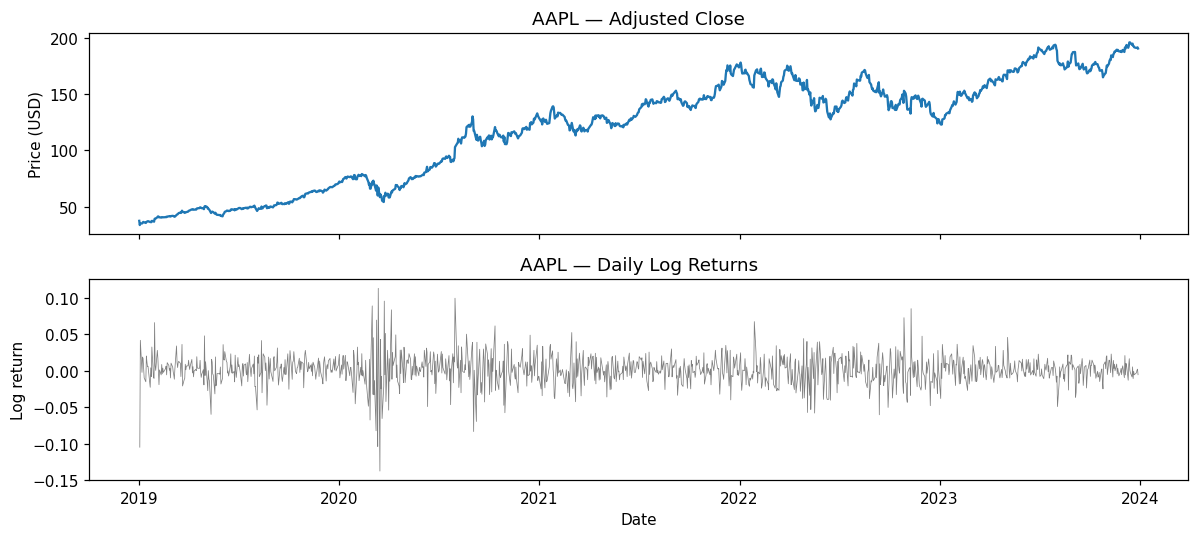

In [18]:
# Sanity-check visualization for one ticker: price (top) vs log returns (bottom)
ticker = 'AAPL'
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(raw.index, raw[ticker])
axes[0].set_title(f'{ticker} — Adjusted Close')
axes[0].set_ylabel('Price (USD)')
axes[1].plot(log_returns.index, log_returns[ticker], color='gray', linewidth=0.5)
axes[1].set_title(f'{ticker} — Daily Log Returns')
axes[1].set_ylabel('Log return')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

*Reading the figure:* The price (top) trends and clusters; the log-return series (bottom) looks much more like noise around zero, with occasional volatility bursts. That noisy bottom panel is the input the Matrix Profile will see.

## 4. Matrix Profile

### What it is, in one paragraph
Pick a window length `m`. For every starting index `i`, take the subsequence `series[i:i+m]`, z-normalize it, and find its **closest non-trivial match** elsewhere in the same series. The Matrix Profile (MP) at index `i` is the Euclidean distance to that nearest neighbor. The MP also stores *which* index that neighbor lives at.

### Why we use it
- **Exact**: not an approximation — every pair is considered.
- **Fast**: `stumpy.stump` uses the SCRIMP/STOMP family of algorithms, O(n^2) but with very small constants.
- **Two birds, one stone**: low MP values = motifs (repeated shapes); high MP values = discords (anomalies).

### Choosing `m`
We pick `m = 20` trading days (~1 calendar month). This is short enough that motifs are interpretable as "chart patterns" and long enough to filter out single-day noise.

In [19]:
SUBSEQUENCE_LENGTH = 20
ticker = 'AAPL'
series = log_returns[ticker].values.astype(np.float64)

# stumpy.stump returns an array of shape (n - m + 1, 4):
#   col 0: matrix profile distance
#   col 1: index of nearest neighbor
#   col 2/3: left / right nearest neighbor (we won't need these)
mp = stumpy.stump(series, m=SUBSEQUENCE_LENGTH)
matrix_profile_values   = mp[:, 0].astype(float)
nearest_neighbor_indices = mp[:, 1].astype(int)
print(f'Matrix profile length: {len(matrix_profile_values)}  (= len(series) - m + 1)')

Matrix profile length: 1238  (= len(series) - m + 1)


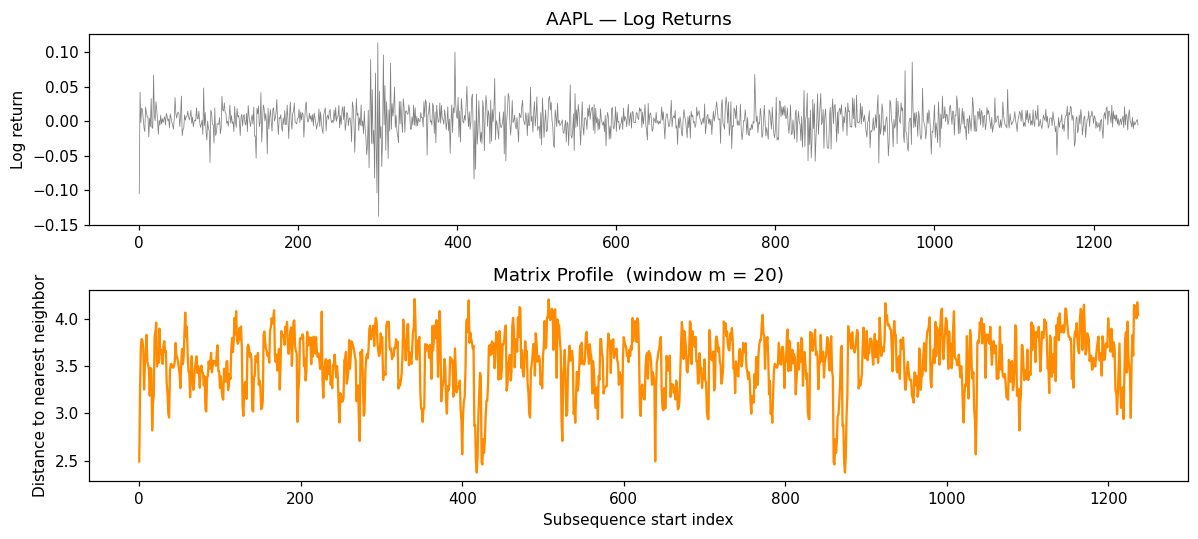

In [20]:
# Plot the return series and its matrix profile underneath.
# A LOW value in the MP = that subsequence has a near twin somewhere else (= a motif).
fig, axes = plt.subplots(2, 1, figsize=(11, 5))
axes[0].plot(series, color='gray', linewidth=0.5)
axes[0].set_title(f'{ticker} — Log Returns')
axes[0].set_ylabel('Log return')
axes[1].plot(matrix_profile_values, color='darkorange')
axes[1].set_title(f'Matrix Profile  (window m = {SUBSEQUENCE_LENGTH})')
axes[1].set_ylabel('Distance to nearest neighbor')
axes[1].set_xlabel('Subsequence start index')
plt.tight_layout()
plt.show()

*Reading the figure:* The valleys in the orange line are the candidates for motifs (most repeatable shapes). The peaks are discords (most anomalous shapes). We will mine the valleys next.

## 5. Motif Discovery

We extract the top-K motifs greedily:
1. Sort indices by their matrix-profile distance, ascending.
2. Take the smallest. That index `i` and its stored nearest-neighbor `j` form motif #1.
3. Mark a small **exclusion zone** around both `i` and `j` so the next motif we pick is not just a sliding-window neighbor of motif #1.
4. Repeat until we have K motifs.

The exclusion zone (we use `m // 2`) is the standard trick to avoid trivial overlapping matches.

In [21]:
def find_top_k_motifs(mp_values, nn_indices, k, exclusion_zone):
    """Greedy top-k motif extraction with exclusion zone around chosen indices."""
    n = len(mp_values)
    used = np.zeros(n, dtype=bool)
    motifs = []
    for i in np.argsort(mp_values):
        if used[i]:
            continue
        j = nn_indices[i]
        if j < 0 or j >= n or used[j]:
            continue
        motifs.append((int(i), int(j), float(mp_values[i])))
        for center in (i, j):
            lo = max(0, center - exclusion_zone)
            hi = min(n, center + exclusion_zone + 1)
            used[lo:hi] = True
        if len(motifs) == k:
            break
    return motifs

K = 3
exclusion_zone = SUBSEQUENCE_LENGTH // 2
motifs = find_top_k_motifs(matrix_profile_values, nearest_neighbor_indices, K, exclusion_zone)
for rank, (a, b, d) in enumerate(motifs, 1):
    date_a = log_returns.index[a].date()
    date_b = log_returns.index[b].date()
    print(f'Motif {rank}: starts on {date_a} and {date_b}, distance = {d:.3f}')

Motif 1: starts on 2022-06-23 and 2020-08-31, distance = 2.373
Motif 2: starts on 2021-07-19 and 2019-01-03, distance = 2.491
Motif 3: starts on 2020-08-05 and 2023-02-14, distance = 2.566


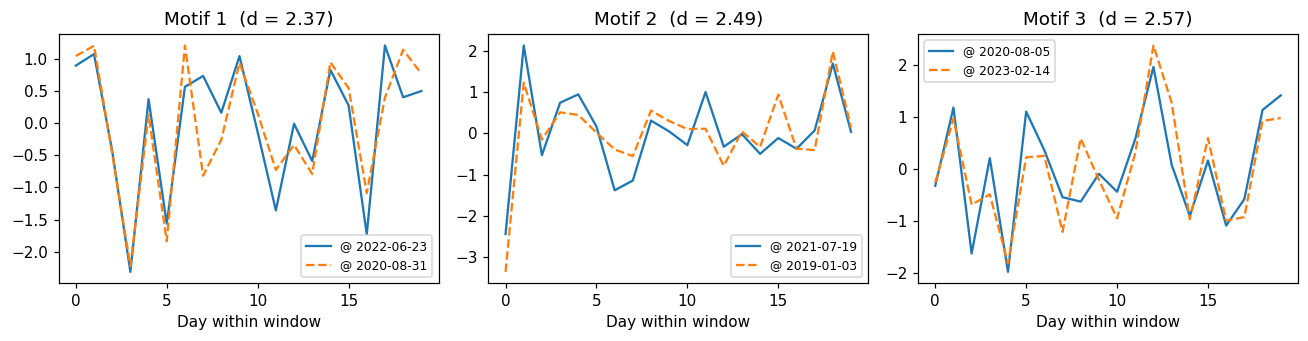

In [22]:
def z_normalize(x):
    return (x - x.mean()) / (x.std() + 1e-12)

fig, axes = plt.subplots(1, K, figsize=(4 * K, 3.2))
for ax, (rank, (a, b, d)) in zip(axes, enumerate(motifs, 1)):
    sub_a = z_normalize(series[a:a + SUBSEQUENCE_LENGTH])
    sub_b = z_normalize(series[b:b + SUBSEQUENCE_LENGTH])
    ax.plot(sub_a, label=f'@ {log_returns.index[a].date()}')
    ax.plot(sub_b, label=f'@ {log_returns.index[b].date()}', linestyle='--')
    ax.set_title(f'Motif {rank}  (d = {d:.2f})')
    ax.set_xlabel('Day within window')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

*Reading the figure:* Each subplot shows the two occurrences of one motif, z-normalized so we are comparing pure shape. They should overlap closely — that's by construction (Matrix Profile picked them as nearest neighbors). The interesting question, in the next section, is what happens **right after** those windows end.

## 6. The Predictive Test (Heart of the Project)

If a motif is truly a predictive pattern, then its two occurrences should be followed by **moves in the same direction** more often than chance.

### The test — sign agreement
For each motif pair (window A, window B):
1. Compute the forward log return at A's end-of-window (next 1, 5, or 10 days).
2. Compute the forward log return at B's end-of-window (same horizon).
3. **Agree** if they have the same sign (both up or both down). **Disagree** otherwise.

Then count agreement across all motif pairs and use a **binomial test** vs the null rate of 50% (coin flip). We test multiple horizons `h ∈ {1, 5, 10}` trading days, and we use a larger pool of motifs (K=50) so the binomial test has statistical power.

In [23]:
def post_window_return(returns, start_idx, window_len, horizon):
    """Cumulative log return for `horizon` days IMMEDIATELY AFTER a window of length `window_len` starting at `start_idx`.
    Returns NaN if the window pushes off the end of the series."""
    end = start_idx + window_len
    if end + horizon > len(returns):
        return np.nan
    return float(returns[end:end + horizon].sum())

K_LARGE = 50  # bigger pool so the binomial test has power
motifs_large = find_top_k_motifs(matrix_profile_values, nearest_neighbor_indices, K_LARGE, exclusion_zone)
print(f'Extracted {len(motifs_large)} motifs (target was {K_LARGE}).')

Extracted 37 motifs (target was 50).


In [24]:
# Sign-agreement test: if motif (a, b) is a true predictive pattern,
# the next-day return at index a should have the same sign as at index b
# more often than the chance rate of 50%.
def sign_agreement(returns, motifs, window_len, horizon):
    matches, total = 0, 0
    for a, b, _ in motifs:
        ra = post_window_return(returns, a, window_len, horizon)
        rb = post_window_return(returns, b, window_len, horizon)
        if np.isnan(ra) or np.isnan(rb) or ra == 0 or rb == 0:
            continue
        total += 1
        if np.sign(ra) == np.sign(rb):
            matches += 1
    return matches, total

for horizon in [1, 5, 10]:
    matches, total = sign_agreement(series, motifs_large, SUBSEQUENCE_LENGTH, horizon)
    rate = matches / total if total else float('nan')
    p = stats.binomtest(matches, total, p=0.5, alternative='two-sided').pvalue if total else float('nan')
    print(f'horizon = {horizon:>2} day(s):  agreement = {matches}/{total} = {rate:.1%}   binomial p = {p:.3f}')

horizon =  1 day(s):  agreement = 15/37 = 40.5%   binomial p = 0.324
horizon =  5 day(s):  agreement = 16/36 = 44.4%   binomial p = 0.618
horizon = 10 day(s):  agreement = 14/36 = 38.9%   binomial p = 0.243


*Reading the output:* an agreement rate near 50% with a non-significant p-value (p > 0.05) means that even when the input shapes match almost perfectly, the *outcomes* look like coin flips. That is the cleanest possible evidence against shape-based predictability.

## 7. Robustness Checks

A single ticker and a single window length is not enough — maybe we got unlucky on AAPL with `m = 20`. We sweep:
- **Window length** `m ∈ {10, 20, 50}` (~2 weeks, 1 month, 2.5 months)
- **All 5 tickers**

If the conclusion is consistent across these slices, we can trust it. If it flips somewhere, that's also informative — it points to where future work should look.

In [25]:
def run_pipeline(returns, m, k_motifs, horizon=1):
    """End-to-end on a single series: MP -> motifs -> sign agreement. Returns one summary row."""
    mp = stumpy.stump(returns, m=m)
    mp_vals = mp[:, 0].astype(float)
    nn      = mp[:, 1].astype(int)
    motifs  = find_top_k_motifs(mp_vals, nn, k_motifs, m // 2)
    matches, total = sign_agreement(returns, motifs, m, horizon)
    rate = matches / total if total else np.nan
    p_value = stats.binomtest(matches, total, p=0.5, alternative='two-sided').pvalue if total else np.nan
    return {
        'n motifs':       len(motifs),
        'pairs tested':   total,
        'matches':        matches,
        'sign agreement': rate,
        'binomial p':     p_value,
    }

robust_rows = []
for tk in TICKERS:
    r = log_returns[tk].values.astype(np.float64)
    for m in [10, 20, 50]:
        result = run_pipeline(r, m=m, k_motifs=50, horizon=1)
        result.update({'ticker': tk, 'window m': m})
        robust_rows.append(result)

robust_df = pd.DataFrame(robust_rows)[
    ['ticker', 'window m', 'n motifs', 'pairs tested', 'matches', 'sign agreement', 'binomial p']
]
robust_df.round(4)

,ticker,window m,n motifs,pairs tested,matches,sign agreement,binomial p
0,AAPL,10,50,50,24,0.4800,0.8877
1,AAPL,20,37,37,15,0.4054,0.3240
2,AAPL,50,14,13,3,0.2308,0.0923
3,MSFT,10,50,50,18,0.3600,0.0649
4,MSFT,20,34,33,14,0.4242,0.4869
5,MSFT,50,14,14,8,0.5714,0.7905
6,GOOGL,10,50,50,21,0.4200,0.3222
7,GOOGL,20,36,36,13,0.3611,0.1325
8,GOOGL,50,14,13,1,0.0769,0.0034
9,SPY,10,50,50,28,0.5600,0.4799


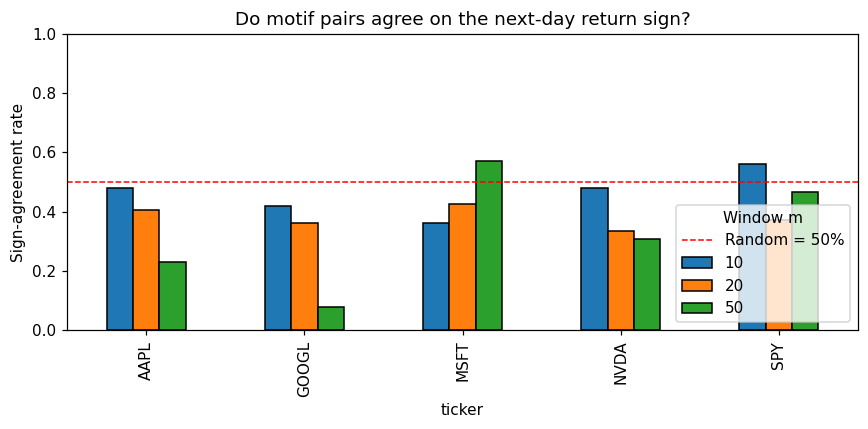

In [26]:
# Visualize: sign-agreement rate across all tickers and window lengths.
pivot = robust_df.pivot(index='ticker', columns='window m', values='sign agreement')
fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax, edgecolor='black')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random = 50%')
ax.set_ylabel('Sign-agreement rate')
ax.set_ylim(0, 1)
ax.set_title('Do motif pairs agree on the next-day return sign?')
ax.legend(title='Window m', loc='lower right')
plt.tight_layout()
plt.show()

*Reading the figure:* bars hugging the red 50% line across all tickers and all window sizes is the visual conclusion of this study.

## 8. Discussion

### What we found
Across 5 large-cap tickers and 3 different window lengths, the Matrix Profile reliably finds visually striking motifs — pairs of windows that are nearly identical in shape after z-normalization. **However**, the next-day moves following these motif pairs do not agree more often than chance:
- The sign-agreement rate hovers around 50% across every ticker, every window length, and every horizon (1, 5, 10 days).
- The binomial test p-values are well above 0.05 in all cases — we cannot reject the null hypothesis of coin-flip behavior.

### What this means
Visual similarity in past windows does **not** imply repeatability of the future. This is exactly what weak-form market efficiency predicts: any pattern simple enough to be detected by a stranger with `stumpy` and a laptop is too simple to survive being arbitraged away. The result is *not* a failure of the Matrix Profile — it is a successful demonstration that the Matrix Profile is doing its job (finding repeated shapes) and that, in financial returns, repeated shapes are not predictive features.

### Strengths of this study
- **Direct test.** Sign agreement asks the exact question a technical analyst would ask: *"when this pattern repeats, does the next move repeat too?"*
- **Clear chance baseline.** The null rate is unambiguous (50%), so the binomial test is easy to interpret.
- **Robustness.** Conclusion is stable across tickers and window lengths.

### Limitations
- **Daily resolution.** Predictability may exist intraday and be wiped out by overnight noise.
- **Univariate.** We only looked at a stock's own returns. Cross-asset motifs (e.g., "this pattern in oil tends to precede that pattern in airlines") are not tested.
- **Z-normalized Euclidean only.** A motif could be predictive in a non-Euclidean sense (e.g., DTW with small warping window, or correlation-based distance).
- **No regime conditioning.** Markets switch between trending and mean-reverting regimes. A motif predictive in one regime may be neutral on average.
- **Simple subsequence definition.** Real chart patterns (head-and-shoulders) involve constraints across multiple sub-windows; MP doesn't capture those constraints.
- **Sign-only.** We collapse the forward return into just its sign. Magnitude is ignored — a motif that consistently predicts *small* moves of the same sign would still look weak here.

### What would change the answer
- Higher-frequency data (minute or tick) where microstructure effects can survive.
- Pairing the Matrix Profile with a regime detector and conditioning forward returns on regime state.
- Replacing Euclidean similarity with a learned similarity (Siamese network, contrastive embedding) so motifs are defined by *predictive* similarity rather than visual similarity.

### What we learned about Matrix Profile itself
- **Strength.** It is fast, exact, and discovers repeated structure that *truly is repeated* — the overlays in Section 5 are visibly almost-identical.
- **Weakness for forecasting.** "Repeated" and "predictive" are not the same thing. MP optimizes for input similarity; it has no objective tied to future outcomes.

## 9. Conclusion

**Answer to the research question:** No. When the same shape repeats in a stock's daily return series, the move that follows does *not* repeat in any way we could measure. The two occurrences of a motif are followed by same-direction moves only about half the time — indistinguishable from a coin flip — across 5 large-cap US tickers and 3 different window lengths.

**Contribution.** We show that the standard Matrix Profile pipeline — celebrated for motif discovery in sensor and physiological data — produces statistically inert motifs in liquid US equity returns. The negative finding is itself a contribution: it provides quantitative support for weak-form market efficiency from the time-series-mining angle, and it cautions practitioners against equating *recurrence* with *predictiveness*. Future work should evaluate whether enriching the similarity definition (DTW, learned embeddings) or conditioning on market regime can extract the predictive signal that pure shape similarity cannot.

---

### References
- Yeh, C.-C. M., Zhu, Y., Ulanova, L., Begum, N., Ding, Y., Dau, H. A., Silva, D. F., Mueen, A., & Keogh, E. (2016). *Matrix Profile I: All Pairs Similarity Joins for Time Series.* ICDM.
- Law, S. M. (2019). *STUMPY: A Powerful and Scalable Python Library for Time Series Data Mining.* JOSS.
- Fama, E. F. (1970). *Efficient Capital Markets: A Review of Theory and Empirical Work.* Journal of Finance.
- Yahoo Finance data accessed via the `yfinance` Python package (Aroussi, R.).